In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from math import pi, gcd
from qiskit import *
from qiskit import transpile
from qiskit.circuit import *
from qiskit.circuit.library import *
from qiskit.quantum_info.operators import Operator
from qiskit_aer import AerSimulator, StatevectorSimulator
from scipy import optimize, linalg
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

In [ ]:
from scipy.stats import norm as gaussian

#We consider that eta is the parameter defining the suppression limit of the energy. 
#Thanks to the article's development, we can deduce that for a gaussian law for tn, we can define eta as 1/TRMS. (without considering the number of ancillas)

#Therefore : 

def rodeo_random(N_ancillas, phi_size, H, E, phi_init, mu, sigma, T_max=10, type="gaussian"):
    q = QuantumRegister(N_ancillas)
    phi = QuantumRegister(phi_size)
    cq = ClassicalRegister(N_ancillas)
    cphi = ClassicalRegister(phi_size)
    qc = QuantumCircuit(q, phi, cq, cphi)

    # Initialize phi register to the given state vector
    qc.initialize(phi_init, phi)

    # Define the t_n values
    if type == "random":
        ts = np.random.uniform(0, T_max, N_ancillas)
    elif type == "quantile":
        # Deterministic quantiles of a Gaussian: reduces variance vs uniform random
        # Gaussian centered at T_max/2, std T_max/4 so values stay mostly in [0, T_max]
        quantiles = np.arange(1, N_ancillas + 1) / (N_ancillas + 1)
        ts = gaussian.ppf(quantiles, loc=T_max / 2, scale=T_max / 4)
    elif type == "geometric":
        # Geometrically spaced from T_max/10 to T_max
        # Covers multiple time scales → breaks resonances that affect uniform/quantile spacings
        ts = np.geomspace(T_max / 10, T_max, N_ancillas)
    elif type == "gaussian":
        ts = np.random.normal(mu, sigma, N_ancillas)
    else:
        raise ValueError(f"Unknown type '{type}'. Use 'random', 'quantile' or 'geometric'.")

    for i in range(N_ancillas):
        t = ts[i]
        qc.h(q[i])

        # Controlled-U(t) = controlled exp(-iHt)
        U = expm(-1j * H * t)
        U_gate = UnitaryGate(U, label="exp(-iHt)")
        cU_gate = U_gate.control(1)
        qc.append(cU_gate, [q[i]] + list(phi))  # ancilla is control, phi is target
        #check in the course. 

        # Phase kick: e^{iEt} on ancilla to select eigenvalue E
        qc.p(E * t, q[i])

        qc.h(q[i])
        qc.measure(q[i], cq[i])  # success if 0

    qc.measure(phi, cphi)

    # Transpile to decompose UnitaryGate into native gates before running
    simulator = AerSimulator()
    qc_t = transpile(qc, simulator)
    job = simulator.run(qc_t, shots=1000)
    result = job.result()
    counts = result.get_counts()
    return counts


In [ ]:
# Simple example: 1-qubit Hamiltonian H = Z (Pauli Z)
# Eigenvalues: E = +1 (eigenstate |0⟩), E = -1 (eigenstate |1⟩)

H = np.array([[1, 0],
              [0, -1]], dtype=complex)

E_target = 1.0
N_ancillas = 3
phi_size = 1

# Start from an equal superposition |+⟩ = (|0⟩ + |1⟩)/√2
# The rodeo algorithm should project it onto |0⟩ (eigenstate of E=+1)
phi_init = np.array([1, 1]) / np.sqrt(2)

counts = rodeo_random(N_ancillas=N_ancillas, phi_size=phi_size, H=H, E=E_target,
                      phi_init=phi_init, mu = 0, sigma = 10, T_max=10)

# Qiskit bitstring order (left to right): cphi | cq
# cphi is the last register added → leftmost phi_size bits
# cq is the first register added  → rightmost N_ancillas bits
success_counts = {k: v for k, v in counts.items() if k[-N_ancillas:] == '0' * N_ancillas}

total_shots = sum(counts.values())
success_shots = sum(success_counts.values())

print(f"Total shots:   {total_shots}")
print(f"Success shots (all ancillas = 0): {success_shots}")
print(f"Success rate:  {success_shots / total_shots:.2%}")
print()
print("Phi register outcomes after successful projection:")
for bitstring, count in sorted(success_counts.items(), key=lambda x: -x[1]):
    phi_bits = bitstring[:phi_size]  # leftmost bits = cphi
    print(f"  phi = |{phi_bits}⟩ : {count} shots")


Total shots:   1000
Success shots (all ancillas = 0): 489
Success rate:  48.90%

Phi register outcomes after successful projection:
  phi = |0⟩ : 489 shots


In [47]:
# Hamiltonien diagonal : H = diag(1, 1, -1, -1)
# Eigenstates de valeur propre  1 : |00⟩, |01⟩
# Eigenstates de valeur propre -1 : |10⟩, |11⟩

H2 = np.diag([1, 1, -1, -1]).astype(complex)
E_target = 1.0

eigenvalues, eigenvectors = np.linalg.eigh(H2)
print("Eigenvalues:", eigenvalues)
print("Eigenspace E=1  → |00⟩, |01⟩")
print("Eigenspace E=-1 → |10⟩, |11⟩")

N_ancillas = 6
phi_size = 2
phi_init = np.ones(4) / 2.0   # superposition uniforme

counts = rodeo_random(N_ancillas=N_ancillas, phi_size=phi_size, H=H2, E=E_target,
                      phi_init=phi_init, mu = 0, sigma = 10, T_max=15)

success_counts = {k: v for k, v in counts.items() if k[-N_ancillas:] == '0' * N_ancillas}
total_shots   = sum(counts.values())
success_shots = sum(success_counts.values())

correct = sum(v for k, v in success_counts.items() if k[:phi_size] in ('00', '01'))

print(f"\nTotal shots   : {total_shots}")
print(f"Succès        : {success_shots}  ({success_shots/total_shots:.1%})")
print(f"Dans E=1      : {correct}  ({correct/success_shots:.1%} des succès)")
print()
for bits in ['00', '01', '10', '11']:
    c = sum(v for k, v in success_counts.items() if k[:phi_size] == bits)
    print(f"  |{bits}⟩ : {c} shots")


Eigenvalues: [-1. -1.  1.  1.]
Eigenspace E=1  → |00⟩, |01⟩
Eigenspace E=-1 → |10⟩, |11⟩

Total shots   : 1000
Succès        : 508  (50.8%)
Dans E=1      : 504  (99.2% des succès)

  |00⟩ : 242 shots
  |01⟩ : 262 shots
  |10⟩ : 2 shots
  |11⟩ : 2 shots


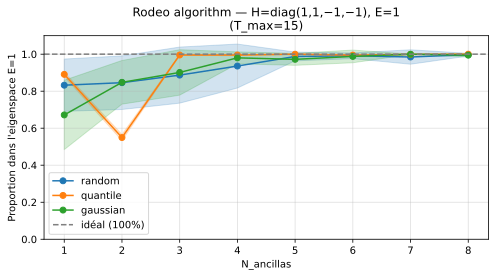

In [52]:
# Proportion de succès dans l'eigenspace E=1 (= |00⟩ ou |01⟩) vs N_ancillas

phi_init = np.ones(4) / 2.0
N_range = list(range(1, 9))
n_runs = 10

def proportion_correct(counts, N_ancillas, phi_size):
    success = {k: v for k, v in counts.items() if k[-N_ancillas:] == '0' * N_ancillas}
    total = sum(success.values())
    if total == 0:
        return np.nan
    correct = sum(v for k, v in success.items() if k[:phi_size] in ('00', '01'))
    return correct / total

results = {"random": [], "quantile": [], "gaussian" : []}
for n in N_range:
    for t in ["random", "quantile", "gaussian"]:
        vals = [proportion_correct(
                    rodeo_random(n, 2, H2, E_target, phi_init,mu = 0, sigma = 100, T_max=15, type=t),
                    n, 2)
                for _ in range(n_runs)]
        results[t].append(vals)

fig, ax = plt.subplots(figsize=(7, 4))
colors = {"random": "tab:blue", "quantile": "tab:orange", "gaussian" : "tab:green"}
for t in ["random", "quantile", "gaussian"]:
    means = [np.nanmean(r) for r in results[t]]
    stds  = [np.nanstd(r)  for r in results[t]]
    ax.plot(N_range, means, marker='o', label=t, color=colors[t])
    ax.fill_between(N_range,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    alpha=0.2, color=colors[t])

ax.axhline(1.0, color='gray', linestyle='--', label='idéal (100%)')
ax.set_xlabel("N_ancillas")
ax.set_ylabel("Proportion dans l'eigenspace E=1")
ax.set_title("Rodeo algorithm — H=diag(1,1,−1,−1), E=1\n(T_max=15)")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
